<font size="6"><b>Lokalizacja punktu w przestrzeni dwuwymiarowej – metoda trapezowa</b></font>

<font size="4"><b>Używane biblioteki: </b></font>

In [1]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
import numpy as np
from bitalg.visualizer.main import Visualizer
import json
import tkinter as tk
import matplotlib
import random

<font size="4"><b>Ustawienie globalnych parametów</b></font>

In [2]:
segments = []
current_points = []
fig, ax = None, None
eps = 1e-9

<font size="4"><b>Funkcje pomocnicze</b></font>

<font size="3">Te funkcje wykonują obliczenia geometryczne, takie jak sprawdzanie orientacji punktów, przynależności do odcinka czy unikalności współrzędnych.</font>

In [3]:
def is_vertical(x1, x2):
    return abs(x1 - x2) < eps
    
def unique_x(x1, y1, x2, y2):
    for p1, p2 in segments:
        if (abs(p1[0] - x1) < eps and abs(p1[1] - y1) >= eps) or \
           (abs(p2[0] - x2) < eps and abs(p2[1] - y2) >= eps):
            return False
    return True
    
def orientation(x1, y1, x2, y2, x3, y3):
    val = (y2 - y1) * (x3 - x2) - (x2 - x1) * (y3 - y2)
    if abs(val) < eps:
        return 0
    return 1 if val > 0 else -1
    
def point_on_segment(px, py, x1, y1, x2, y2):
    return (px <= max(x1, x2) + eps and px >= min(x1, x2) - eps and 
            py <= max(y1, y2) + eps and py >= min(y1, y2) - eps)
def draw_test(line_segments,title=""):
    vis = Visualizer()
    vis.add_title(title)
    vis.add_line_segment(line_segments)
    vis.save(title)
    vis.show()


<font size="4"><b>Zarządzanie odcinkami</b></font>

Te funkcje sprawdzają przecinianie się odcinków i dodają nowe odcinki, zapewniając brak kolizji.

In [4]:
def segments_intersect(x1, y1, x2, y2):
    for p1, p2 in segments:
        o1 = orientation(x1, y1, x2, y2, p1[0], p1[1])
        o2 = orientation(x1, y1, x2, y2, p2[0], p2[1])
        o3 = orientation(p1[0], p1[1], p2[0], p2[1], x1, y1)
        o4 = orientation(p1[0], p1[1], p2[0], p2[1], x2, y2)
        
        if o1 != o2 and o3 != o4:
            return True
        
        if o1 == 0 and point_on_segment(p1[0], p1[1], x1, y1, x2, y2):
            return True
        if o2 == 0 and point_on_segment(p2[0], p2[1], x1, y1, x2, y2):
            return True
        if o3 == 0 and point_on_segment(x1, y1, p1[0], p1[1], p2[0], p2[1]):
            return True
        if o4 == 0 and point_on_segment(x2, y2, p1[0], p1[1], p2[0], p2[1]):
            return True
    
    return False
def add_segment(x1, y1, x2, y2):
    if x1 > x2:
        x1, x2, y1, y2 = x2, x1, y2, y1
    
    if is_vertical(x1, x2):
        return False
    if not unique_x(x1, y1, x2, y2):
        return False
    if segments_intersect(x1, y1, x2, y2):
        return False
    
    segments.append(((x1, y1), (x2, y2)))
    return True


<font size="4"></font>

<font size="5"><b>Funkcje interfejsu graficznego</b></font>



In [5]:
def redraw():
    ax.clear()
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_title("Kliknij dwa razy aby dodać odcinek")
    for p1, p2 in segments:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k-', marker='o', markersize=4)
    if len(current_points) == 1:
        ax.plot(current_points[0][0], current_points[0][1], 'ro', markersize=6)
    
    fig.canvas.draw()

def on_click(event):
    global current_points
    if event.inaxes != ax:
        return
    current_points.append((event.xdata, event.ydata))
    if len(current_points) == 2:
        x1, y1 = current_points[0]
        x2, y2 = current_points[1]
        add_segment(x1, y1, x2, y2)
        current_points = []
    
    redraw()
def start_generator():
    global fig, ax, segments, current_points
    segments = []
    current_points = []
    matplotlib.use('TkAgg')
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.subplots_adjust(bottom=0.15)

    clear_ax = plt.axes([0.1, 0.02, 0.15, 0.055])
    clear_button = Button(clear_ax, 'Wyczyść')
    clear_button.on_clicked(clear_all)
    
    gen_ax = plt.axes([0.28, 0.02, 0.15, 0.055])
    gen_button = Button(gen_ax, 'Generuj')
    gen_button.on_clicked(generate_random_dialog)
    
    save_ax = plt.axes([0.46, 0.02, 0.15, 0.055])
    save_button = Button(save_ax, 'Zapisz')
    save_button.on_clicked(save_segments_dialog)
    
    load_ax = plt.axes([0.64, 0.02, 0.15, 0.055])
    load_button = Button(load_ax, 'Wczytaj')
    load_button.on_clicked(load_segments_dialog)
    
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_title("Kliknij dwa razy aby dodać odcinek")
    
    fig.canvas.mpl_connect('button_press_event', on_click)
    plt.show()




<font size="5"><b>Funkcje zarządzające akcjami użytkownika</b></font>

In [6]:
def clear_all(event=None):
    global segments, current_points
    segments = []
    current_points = []
    redraw()
def save_segments_dialog(event=None):
    root = tk.Tk()
    root.withdraw()
    filepath = tk.filedialog.asksaveasfilename(defaultextension=".json",filetypes=[("JSON", "*.json"), ("All", "*.*")],initialfile="segments.json")
    if filepath:
        with open(filepath, 'w') as f:
            json.dump(segments, f)
    root.destroy()

def load_segments_dialog(event=None):
    global segments, current_points
    root = tk.Tk()
    root.withdraw()
    filepath = tk.filedialog.askopenfilename(filetypes=[("JSON", "*.json"), ("All", "*.*")])
    if filepath:
        with open(filepath, 'r') as f:
            segments = json.load(f)
        current_points = []
        redraw()
    root.destroy()

def generate_random_dialog(event=None):
    dialog = tk.Toplevel()  # Use Toplevel instead of Tk
    dialog.title("Generuj losowe odcinki")
    dialog.geometry("280x230")
    dialog.grab_set()  # Make it modal
    
    fields = {
        'count': tk.StringVar(value="100"),
        'x_min': tk.StringVar(value="0"),
        'x_max': tk.StringVar(value="100"),
        'y_min': tk.StringVar(value="0"),
        'y_max': tk.StringVar(value="100")
    }
    labels = ['Liczba odcinków:', 'x_min:', 'x_max:', 'y_min:', 'y_max:']
    for i, (key, label) in enumerate(zip(fields.keys(), labels)):
        tk.Label(dialog, text=label).grid(row=i, column=0, padx=10, pady=8, sticky="e")
        tk.Entry(dialog, textvariable=fields[key], width=15).grid(row=i, column=1, padx=10, pady=8)
    
    def on_ok():
        try:
            count = int(fields['count'].get())
            x_min = float(fields['x_min'].get())
            x_max = float(fields['x_max'].get())
            y_min = float(fields['y_min'].get())
            y_max = float(fields['y_max'].get())
            dialog.destroy()
            generate_random(count, x_min, x_max, y_min, y_max)
        except ValueError:
            return
    
    btn_frame = tk.Frame(dialog)
    btn_frame.grid(row=5, column=0, columnspan=2, pady=10)
    tk.Button(btn_frame, text="OK", command=on_ok, width=10).pack(side="left", padx=5)
    tk.Button(btn_frame, text="Anuluj", command=dialog.destroy, width=10).pack(side="left", padx=5)
    



<font size="4"><b>Funkcje do generowania losowych odcinków</b></font>

In [7]:
def generate_random(count, x_min, x_max, y_min, y_max):
    global segments, current_points
    segments = []
    current_points = []
    while len(segments) < count:
        x1 = np.random.uniform(x_min, x_max)
        y1 = np.random.uniform(y_min, y_max)
        x2 = np.random.uniform(x_min, x_max)
        y2 = np.random.uniform(y_min, y_max)
        add_segment(x1, y1, x2, y2)  
    redraw()
def generate_segments_list(count=100, x_min=0, x_max=100, y_min=0, y_max=100):
    temp_segments = []
    def can_add(x1, y1, x2, y2):
        if x1 > x2:
            x1, x2, y1, y2 = x2, x1, y2, y1
        if is_vertical(x1, x2):
            return False
        for p1, p2 in temp_segments:
            if (p1[0] == x1 and p1[1] != y1) or (p2[0] == x2 and p2[1] != y2):
                return False
        for p1, p2 in temp_segments:
            o1 = orientation(x1, y1, x2, y2, p1[0], p1[1])
            o2 = orientation(x1, y1, x2, y2, p2[0], p2[1])
            o3 = orientation(p1[0], p1[1], p2[0], p2[1], x1, y1)
            o4 = orientation(p1[0], p1[1], p2[0], p2[1], x2, y2)
            
            if o1 != o2 and o3 != o4:
                return False
            if o1 == 0 and point_on_segment(p1[0], p1[1], x1, y1, x2, y2):
                return False
            if o2 == 0 and point_on_segment(p2[0], p2[1], x1, y1, x2, y2):
                return False
            if o3 == 0 and point_on_segment(x1, y1, p1[0], p1[1], p2[0], p2[1]):
                return False
            if o4 == 0 and point_on_segment(x2, y2, p1[0], p1[1], p2[0], p2[1]):
                return False
        return True
    
    while len(temp_segments) < count:
        x1 = np.random.uniform(x_min, x_max)
        y1 = np.random.uniform(y_min, y_max)
        x2 = np.random.uniform(x_min, x_max)
        y2 = np.random.uniform(y_min, y_max)
        if x1 > x2:
            x1, x2, y1, y2 = x2, x1, y2, y1
        if can_add(x1, y1, x2, y2):
            temp_segments.append(((x1, y1), (x2, y2)))
    return temp_segments


<font size="4"><b>Funkcje operacji na plikach i dostępu do danych</b></font>

In [8]:

def get_segments():
    return segments

def load_segments_from_file(filepath):
    with open(filepath, 'r') as f:
        data = json.load(f)
        return [tuple(tuple(point) for point in segment) for segment in data]

def save_segments_to_file(segments_list, filepath):
    # Ensure .json extension is added
    if not filepath.endswith('.json'):
        filepath += '.json'
    with open(filepath, 'w') as f:
        json.dump(segments_list, f)



In [9]:
start_generator()

In [10]:
print(get_segments())

[[[25.806451612903228, 77.3972602739726], [83.35483870967742, 82.53424657534246]], [[58.96774193548387, 67.80821917808218], [72.38709677419355, 66.60958904109589]], [[18.193548387096772, 41.78082191780821], [88.90322580645162, 47.43150684931507]], [[36.12903225806451, 69.6917808219178], [51.35483870967742, 54.45205479452055]], [[7.870967741935484, 38.86986301369862], [15.612903225806452, 82.70547945205479]]]


<font size="4"><b>Wygenerowany test: </b></font>

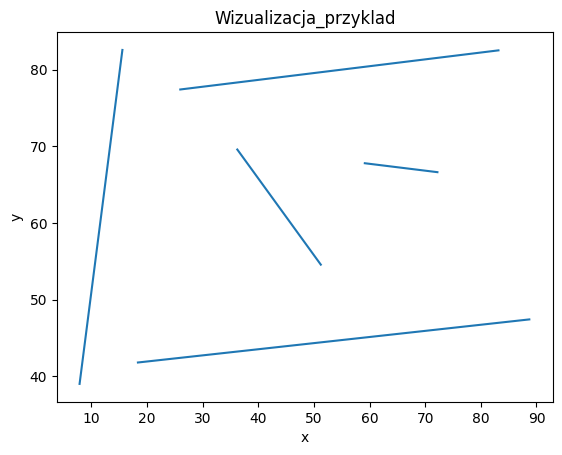

In [11]:
%matplotlib inline
draw_test(get_segments(),"Wizualizacja_przyklad")

<font size="6"><b>Dane testowe</b></font>

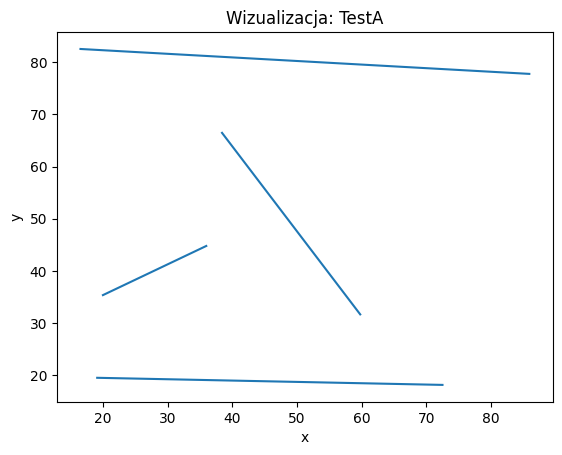

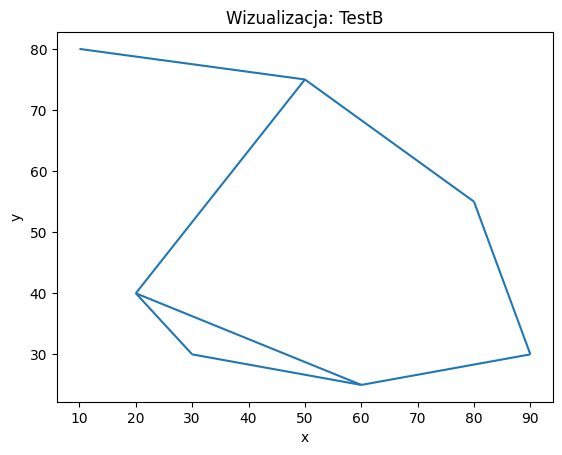

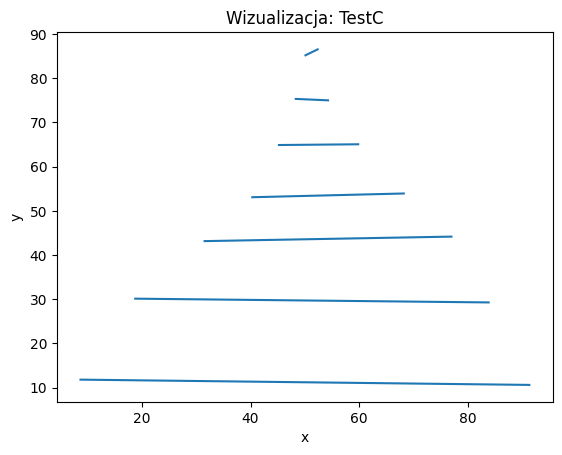

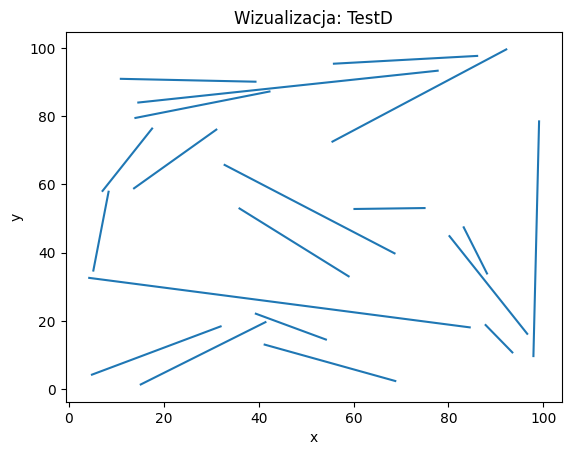

In [12]:
tests_name=["TestA","TestB","TestC","TestD"]
tests_segments=[]
for name in tests_name:
    tests_segments.append(load_segments_from_file(name+".json"))
i=0
for i in range(len(tests_name)):
    %matplotlib inline
    vis = Visualizer()
    draw_test(tests_segments[i],"Wizualizacja: "+tests_name[i])
    
    
    
    

<font size="6"><b>Implementacja algorytmu</b></font>

<font size="4">Podstawowe obiekty geometryczne</font>

<font size="4">Te funkcje obsługują obliczenia geometryczne, takie jak orientacja punktów czy wyszukiwanie trapezów.</font>

<font size="4">Te funkcje budują i aktualizują mapę trapezoidalną</font>

<font size="4"><b>Funkcja zwracająca wynik</b></font>

In [13]:
import random

# --- Klasy danych (Bez zmian w interfejsie) ---

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __repr__(self):
        return f"({self.x:.2f}, {self.y:.2f})"

class Segment:
    def __init__(self, p1, p2):
        # Upewniamy się, że p1 jest lewym końcem (leksykograficznie)
        if p1.x < p2.x or (p1.x == p2.x and p1.y < p2.y):
            self.p1, self.p2 = p1, p2
        else:
            self.p1, self.p2 = p2, p1

    def __repr__(self):
        return f"[{self.p1}, {self.p2}]"

class Trapezoid:
    id_counter = 0

    def __init__(self, top, bottom, left_p, right_p):
        self.id = Trapezoid.id_counter
        Trapezoid.id_counter += 1
        self.top = top
        self.bottom = bottom
        self.left_p = left_p
        self.right_p = right_p
        
        # Sąsiedzi
        self.upper_left = None
        self.lower_left = None
        self.upper_right = None
        self.lower_right = None
        
        # Węzeł w grafie (liść)
        self.Node = None

    def __repr__(self):
        return f"T{self.id}"

# --- Klasy węzłów (Bez zmian w interfejsie) ---

class Node:
    def __init__(self):
        self.left = None
        self.right = None
        self.parents = []

    def set_left(self, child):
        self.left = child
        if child:
            child.parents.append(self)

    def set_right(self, child):
        self.right = child
        if child:
            child.parents.append(self)
            
    # Metoda pomocnicza do zamiany dziecka (potrzebna do aktualizacji DAG)
    def replace_child(self, old_child, new_child):
        if self.left == old_child:
            self.set_left(new_child)
        if self.right == old_child:
            self.set_right(new_child)

class XNode(Node):
    def __init__(self, point, left_child, right_child):
        super().__init__()
        self.point = point
        self.set_left(left_child)
        self.set_right(right_child)

class YNode(Node):
    def __init__(self, segment, up_child, down_child):
        super().__init__()
        self.segment = segment
        self.set_left(up_child)     # left child to "above" (zgodnie z kodem kolegi)
        self.set_right(down_child)  # right child to "below"

class SinkNode(Node):
    def __init__(self, trapezoid):
        super().__init__()
        self.trapezoid = trapezoid
        trapezoid.Node = self

# --- Funkcje pomocnicze i logiczne ---

# > 0 jeżeli p jest nad segmentem (orientacja)
def is_up(segment, p):
    return ((segment.p2.x - segment.p1.x) * (p.y - segment.p1.y) - 
            (segment.p2.y - segment.p1.y) * (p.x - segment.p1.x)) > 0

def locate(node, p):
    while not isinstance(node, SinkNode):
        if isinstance(node, XNode):
            # Używamy prostej logiki: jeśli p.x < node.x idź w lewo
            if p.x < node.point.x:
                node = node.left
            elif p.x == node.point.x:
                 # Przypadek równości (dla uproszczenia jak u kolegi: prawo)
                 # Chyba że punkt jest identyczny leksykograficznie, ale tu upraszczamy
                 node = node.right 
            else:
                node = node.right
        elif isinstance(node, YNode):
            if is_up(node.segment, p):
                node = node.left
            else:
                node = node.right
    return node.trapezoid

def init_tree(min_x, min_y, max_x, max_y):
    Trapezoid.id_counter = 0
    # Tworzymy duży bounding box
    p_left = Point(min_x, min_y)  # Uproszczenie: punkt lewy
    p_right = Point(max_x, max_y) # Uproszczenie: punkt prawy
    
    # Linie graniczne
    top_edge = Segment(Point(min_x, max_y), Point(max_x, max_y))
    bottom_edge = Segment(Point(min_x, min_y), Point(max_x, min_y))
    
    first_trapezoid = Trapezoid(top_edge, bottom_edge, p_left, p_right)
    root = SinkNode(first_trapezoid)
    return root

def find_intersected_trapezoids(root, new_segment):
    intersected = []
    # 1. Znajdź trapez zawierający p1
    current_trap = locate(root, new_segment.p1)
    intersected.append(current_trap)
    
    # 2. Iteruj w prawo aż do p2
    while new_segment.p2.x > current_trap.right_p.x:
        # Decyzja: czy idziemy do górnego czy dolnego sąsiada?
        if current_trap.upper_right is None: # Brak górnego, idź w dolny
             current_trap = current_trap.lower_right
        elif current_trap.lower_right is None: # Brak dolnego, idź w górny
             current_trap = current_trap.upper_right
        else:
            # Sprawdź geometrycznie czy prawy punkt trapezu jest nad czy pod nowym odcinkiem
            if is_up(new_segment, current_trap.right_p):
                current_trap = current_trap.lower_right
            else:
                current_trap = current_trap.upper_right
        
        intersected.append(current_trap)
        
    return intersected

# --- Funkcje aktualizacji grafu (na wzór kolegi: replace_node, replace_trap_node_left/right) ---

def _replace_node_in_dag(old_node, new_sub_root, root):
    if old_node == root:
        return new_sub_root
    
    # Dla każdego rodzica starego węzła, podmień go na nowy pod-korzeń
    # Kopiujemy listę parents, bo podczas set_left/right ona się modyfikuje
    parents_copy = list(old_node.parents)
    for parent in parents_copy:
        parent.replace_child(old_node, new_sub_root)
    
    return root

def _link_left_neighbors(old_trap, new_trap):
    # Przepisanie sąsiadów z lewej starego do nowego
    new_trap.upper_left = old_trap.upper_left
    new_trap.lower_left = old_trap.lower_left
    
    # Aktualizacja wskaźników 'right' u sąsiadów
    if old_trap.upper_left:
        # Jeśli stary był lower_right sąsiada
        if old_trap.upper_left.lower_right == old_trap:
            old_trap.upper_left.lower_right = new_trap
        else:
            old_trap.upper_left.upper_right = new_trap

    if old_trap.lower_left:
        if old_trap.lower_left.upper_right == old_trap:
            old_trap.lower_left.upper_right = new_trap
        else:
            old_trap.lower_left.lower_right = new_trap

def _link_right_neighbors(old_trap, new_trap):
    # Przepisanie sąsiadów z prawej starego do nowego
    new_trap.upper_right = old_trap.upper_right
    new_trap.lower_right = old_trap.lower_right
    
    # Aktualizacja wskaźników 'left' u sąsiadów
    if old_trap.upper_right:
        if old_trap.upper_right.lower_left == old_trap:
            old_trap.upper_right.lower_left = new_trap
        else:
            old_trap.upper_right.upper_left = new_trap
            
    if old_trap.lower_right:
        if old_trap.lower_right.upper_left == old_trap:
            old_trap.lower_right.upper_left = new_trap
        else:
            old_trap.lower_right.lower_left = new_trap

# --- GŁÓWNA LOGIKA ---

def _handle_single_trapezoid(root, old_trap, seg):
    # Logika 1:1 z partition_one
    p = seg.p1
    q = seg.p2
    
    # Budowa poddrzewa: X(p) -> [LeftTrap, X(q)] -> [Y(seg), RightTrap]
    
    # Tworzenie nowych trapezów
    # 1. Lewy
    t_left = Trapezoid(old_trap.top, old_trap.bottom, old_trap.left_p, p)
    t_left.Node = SinkNode(t_left)
    
    # 2. Prawy
    t_right = Trapezoid(old_trap.top, old_trap.bottom, q, old_trap.right_p)
    t_right.Node = SinkNode(t_right)
    
    # 3. Górny (nad segmentem)
    t_top = Trapezoid(old_trap.top, seg, p, q)
    t_top.Node = SinkNode(t_top)
    
    # 4. Dolny (pod segmentem)
    t_bot = Trapezoid(seg, old_trap.bottom, p, q)
    t_bot.Node = SinkNode(t_bot)
    
    # Łączenie sąsiadów (wewnątrz strefy)
    t_left.upper_right = t_top
    t_left.lower_right = t_bot
    t_right.upper_left = t_top
    t_right.lower_left = t_bot
    
    t_top.lower_left = t_left
    t_top.lower_right = t_right
    t_bot.upper_left = t_left
    t_bot.upper_right = t_right
    
    # Łączenie z sąsiadami zewnętrznymi (ze starego trapezu)
    _link_left_neighbors(old_trap, t_left)
    _link_right_neighbors(old_trap, t_right)
    
    # Budowa struktury węzłów
    y_node = YNode(seg, t_top.Node, t_bot.Node)
    x_node_q = XNode(q, y_node, t_right.Node)
    x_node_p = XNode(p, t_left.Node, x_node_q)
    
    return _replace_node_in_dag(old_trap.Node, x_node_p, root)

def _handle_multi_trapezoid(root, traps, seg):
    # Logika 1:1 z partition_mult
    p, q = seg.p1, seg.p2
    
    first_trap = traps[0]
    last_trap = traps[-1]
    
    # --- Obsługa pierwszego trapezu ---
    # Tworzymy poddrzewo dla pierwszego trapezu
    # X(p) -> LeftTrap | Y(seg) -> Top | Bot
    
    t_left = None
    if True: # Zawsze tworzymy lewy (zakładamy że p nie jest na krawędzi dla uproszczenia)
        t_left = Trapezoid(first_trap.top, first_trap.bottom, first_trap.left_p, p)
        t_left.Node = SinkNode(t_left)
        _link_left_neighbors(first_trap, t_left)
        
    t_top = Trapezoid(first_trap.top, seg, p, None) # right_p nieznany na razie
    t_bot = Trapezoid(seg, first_trap.bottom, p, None)
    
    # Węzły
    ynode = YNode(seg, None, None) # Dzieci przypiszemy zaraz
    xnode = XNode(p, t_left.Node, ynode)
    
    # Podmiana w DAG
    root = _replace_node_in_dag(first_trap.Node, xnode, root)
    
    # Logika scalania (merge)
    prev_upper = t_top
    prev_lower = t_bot
    
    # Dołączamy węzły SinkNode tymczasowo
    t_top.Node = SinkNode(t_top)
    t_bot.Node = SinkNode(t_bot)
    ynode.set_left(t_top.Node)
    ynode.set_right(t_bot.Node)
    
    # Łączenie wewnętrzne z lewym
    t_left.upper_right = t_top
    t_left.lower_right = t_bot
    t_top.lower_left = t_left
    t_bot.upper_left = t_left
    
    # Decyzja o scalaniu dla pierwszego trapezu
    # Sprawdzamy czy prawy punkt trapezu jest nad odcinkiem
    is_right_p_above = is_up(seg, first_trap.right_p)
    
    if is_right_p_above:
        # Prawy punkt nad -> dolny trapez będzie kontynuowany, górny się kończy tu
        t_top.right_p = first_trap.right_p
        _link_right_neighbors(first_trap, t_top)
        merge_state = "LOW"
    else:
        # Prawy punkt pod -> górny trapez będzie kontynuowany, dolny się kończy tu
        t_bot.right_p = first_trap.right_p
        _link_right_neighbors(first_trap, t_bot)
        merge_state = "UPP"
        
    
    # --- Obsługa środkowych trapezów ---
    for i in range(1, len(traps) - 1):
        curr_trap = traps[i]
        ynode = YNode(seg, None, None)
        
        if merge_state == "UPP":
            # Kontynuujemy górny, tworzymy nowy dolny
            curr_upper = prev_upper
            # Dodajemy rodzica do istniejącego węzła (w Logice kolegi lista parents)
            curr_upper.Node.parents.append(ynode)
            ynode.left = curr_upper.Node # Ręczne przypięcie (uwaga: set_left dodałby rodzica drugi raz)
            
            curr_lower = Trapezoid(seg, curr_trap.bottom, curr_trap.left_p, None)
            curr_lower.Node = SinkNode(curr_lower)
            ynode.set_right(curr_lower.Node)
            
            _link_left_neighbors(curr_trap, curr_lower)
            
        else: # merge_state == "LOW"
            # Kontynuujemy dolny, tworzymy nowy górny
            curr_lower = prev_lower
            curr_lower.Node.parents.append(ynode)
            ynode.right = curr_lower.Node
            
            curr_upper = Trapezoid(curr_trap.top, seg, curr_trap.left_p, None)
            curr_upper.Node = SinkNode(curr_upper)
            ynode.set_left(curr_upper.Node)
            
            _link_left_neighbors(curr_trap, curr_upper)
            
        root = _replace_node_in_dag(curr_trap.Node, ynode, root)
        
        # Decyzja co dalej
        is_right_p_above = is_up(seg, curr_trap.right_p)
        if is_right_p_above:
            # Górny się kończy
            curr_upper.right_p = curr_trap.right_p
            _link_right_neighbors(curr_trap, curr_upper)
            merge_state = "LOW"
        else:
            # Dolny się kończy
            curr_lower.right_p = curr_trap.right_p
            _link_right_neighbors(curr_trap, curr_lower)
            merge_state = "UPP"
            
        prev_upper = curr_upper
        prev_lower = curr_lower

    # --- Obsługa ostatniego trapezu ---
    ynode = YNode(seg, None, None)
    
    t_right = Trapezoid(last_trap.top, last_trap.bottom, q, last_trap.right_p)
    t_right.Node = SinkNode(t_right)
    _link_right_neighbors(last_trap, t_right)
    
    if merge_state == "UPP":
        curr_upper = prev_upper
        curr_upper.Node.parents.append(ynode)
        curr_upper.right_p = q
        ynode.left = curr_upper.Node
        
        curr_lower = Trapezoid(seg, last_trap.bottom, last_trap.left_p, q)
        curr_lower.Node = SinkNode(curr_lower)
        ynode.set_right(curr_lower.Node)
        
        _link_left_neighbors(last_trap, curr_lower)
    else:
        curr_lower = prev_lower
        curr_lower.Node.parents.append(ynode)
        curr_lower.right_p = q
        ynode.right = curr_lower.Node
        
        curr_upper = Trapezoid(last_trap.top, seg, last_trap.left_p, q)
        curr_upper.Node = SinkNode(curr_upper)
        ynode.set_left(curr_upper.Node)
        
        _link_left_neighbors(last_trap, curr_upper)
        
    # Łączenie z prawym trapezem
    t_right.upper_left = curr_upper
    t_right.lower_left = curr_lower
    curr_upper.lower_right = t_right
    curr_lower.upper_right = t_right
    
    # Węzeł XNode dla q
    xnode = XNode(q, ynode, t_right.Node)
    root = _replace_node_in_dag(last_trap.Node, xnode, root)
    
    return root


def add_segment(root, new_seg):
    # 1. Znajdź wszystkie trapezy przecinane przez odcinek
    traps = find_intersected_trapezoids(root, new_seg)
    
    if not traps:
        return root

    # 2. Sprawdź czy odcinek zawiera się w jednym trapezie (partition_one)
    #    czy przecina wiele (partition_mult)
    
    if len(traps) == 1:
        root = _handle_single_trapezoid(root, traps[0], new_seg)
    else:
        root = _handle_multi_trapezoid(root, traps, new_seg)

    return root

# --- Reszta funkcji (Bez zmian) ---

def get_bounding_box(segments, margin=1.0):
    all_points = []
    for s in segments:
        all_points.extend([s.p1, s.p2])
    if not all_points:
        return 0, 0, 10, 10
    min_x = min(p.x for p in all_points) - margin
    max_x = max(p.x for p in all_points) + margin
    min_y = min(p.y for p in all_points) - margin
    max_y = max(p.y for p in all_points) + margin
    return min_x, min_y, max_x, max_y

def build_trapezoidal_map(segments, seed=None):
    if not segments:
        return None
    segments_copy = segments.copy()
    
    # --- KULOODPORNA POPRAWKA ---
    if seed is not None:
        # Rzutujemy na string (napis). To działa dla liczb, obiektów, wszystkiego.
        # Python nie wywali wtedy błędu o haszowaniu.
        random.seed(str(seed)) 
    # ----------------------------

    random.shuffle(segments_copy)
    min_x, min_y, max_x, max_y = get_bounding_box(segments_copy)
    root = init_tree(min_x, min_y, max_x, max_y)
    for seg in segments_copy:
        root = add_segment(root, seg)
    return root

def run_test(data_from_generator, point):
    test_segments = []
    px, py = point
    query_point = Point(float(px), float(py))
    for (x1, y1), (x2, y2) in data_from_generator:
        p1 = Point(float(x1), float(y1))
        p2 = Point(float(x2), float(y2))
        test_segments.append(Segment(p1, p2))
    
    root = build_trapezoidal_map(test_segments, seed=42)
    found_trap = locate(root, query_point)
    
    print(f"Punkt {query_point} znajduje się w trapezie o ID: {found_trap.id}")
    top_s = found_trap.top
    bot_s = found_trap.bottom
    print(f"Granice trapezu:\n Góra: {top_s.p1} -> {top_s.p2}\n Dół:  {bot_s.p1} -> {bot_s.p2}")
    return root

def get_all_trapezoids(node, visited=None):
    if visited is None:
        visited = set()
    traps = []
    
    def collect(n):
        if n is None or id(n) in visited:
            return
        visited.add(id(n))
        if isinstance(n, SinkNode):
            if n.trapezoid not in traps:
                traps.append(n.trapezoid)
        else:
            if hasattr(n, 'left') and n.left:
                collect(n.left)
            if hasattr(n, 'right') and n.right:
                collect(n.right)
    
    collect(node)
    return traps

In [14]:
formatted_segments=[]
i=0
for (p1_coords, p2_coords) in get_segments():
    p1=Point(float(p1_coords[0]), float(p1_coords[1]))
    p2=Point(float(p2_coords[0]), float(p2_coords[1]))
    formatted_segments.append(Segment(p1, p2))
    i+=1
min_x,min_y,max_x,max_y=get_bounding_box(formatted_segments)
x=random.uniform(min_x,max_x)
y=random.uniform(min_y,max_y)
_=run_test(get_segments(),(x,y))

Punkt (59.68, 62.12) znajduje się w trapezie o ID: 13
Granice trapezu:
 Góra: (58.97, 67.81) -> (72.39, 66.61)
 Dół:  (18.19, 41.78) -> (88.90, 47.43)


<font size="4"><b>Funckje tworzące wizualizacje gotowej mapy trapezowej</b></font>

In [15]:
def get_all_trapezoids(node, visited, traps):
    if node is None or node in visited:
        return 
    visited.add(node)
    if isinstance(node, SinkNode):
        traps.append(node.trapezoid)
    else:
        get_all_trapezoids(node.left, visited, traps)
        get_all_trapezoids(node.right, visited, traps)

def get_y_on_edge(edge, x, eps=1e-9):
    x1, y1 = edge.p1.x, edge.p1.y
    x2, y2 = edge.p2.x, edge.p2.y
    if abs(x2 - x1) < eps:
        return y1
    y = y1 + (y2 - y1) * (x - x1) / (x2 - x1)
    return y

def draw_actual(root):
    vis = Visualizer()
    current_traps = []
    get_all_trapezoids(root, set(), current_traps)

    lines = set()
    for t in current_traps:
        bottom, top = t.bottom, t.top
        left_p, right_p = t.left_p, t.right_p
    
        y_tl = get_y_on_edge(top, left_p.x)
        y_bl = get_y_on_edge(bottom, left_p.x)
        y_tr = get_y_on_edge(top, right_p.x)
        y_br = get_y_on_edge(bottom, right_p.x)

        line_bottom = ((left_p.x, y_bl), (right_p.x, y_br))
        line_top = ((left_p.x, y_tl), (right_p.x, y_tr))
        line_left = ((left_p.x, y_bl), (left_p.x, y_tl))
        line_right = ((right_p.x, y_br), (right_p.x, y_tr))

        lines.add(line_bottom)
        lines.add(line_top)
        lines.add(line_left)
        lines.add(line_right)
    
    vis.add_line_segment(list(lines), color="blue", linestyle="-", alpha=0.5)
    
    return vis 
    

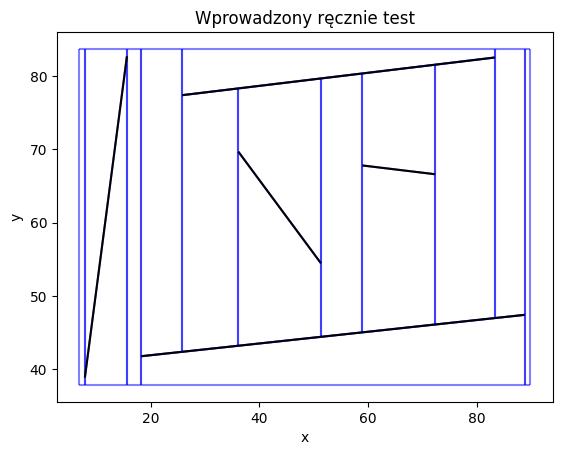

In [16]:
test_segments=[]
for (x1,y1),(x2,y2) in get_segments():
    p1,p2=Point(float(x1),float(y1)),Point(float(x2),float(y2))
    test_segments.append(Segment(p1, p2))
min_x,min_y,max_x,max_y=get_bounding_box(formatted_segments)
x=random.uniform(min_x,max_x)
y=random.uniform(min_y,max_y)
root=build_trapezoidal_map(test_segments,(x,y))
vis=draw_actual(root)
vis.add_title("Wprowadzony ręcznie test")
vis.add_line_segment(get_segments(),color='black')
vis.save("Przyklad_mapa_trapezowa")
vis.show()

<font size="4"><b>Mapy trapezowe dla poszczególnych zbiorów testowych</b></font>

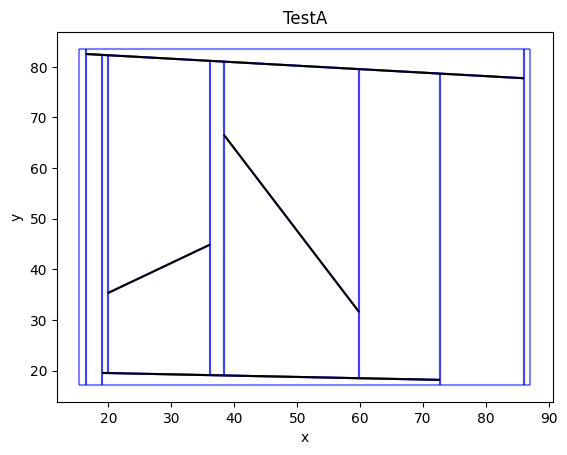

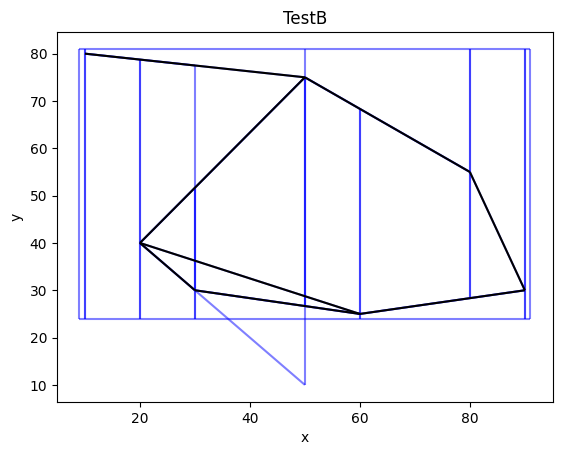

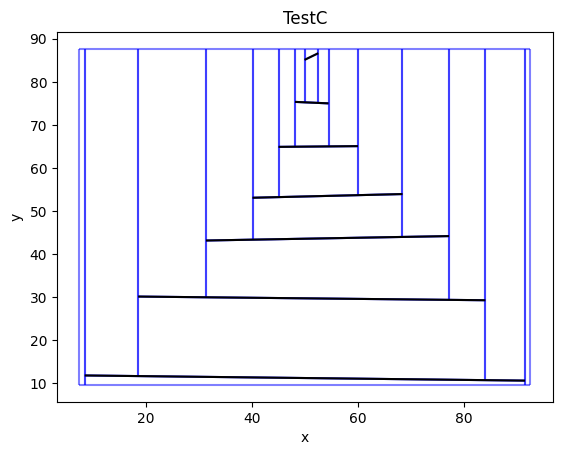

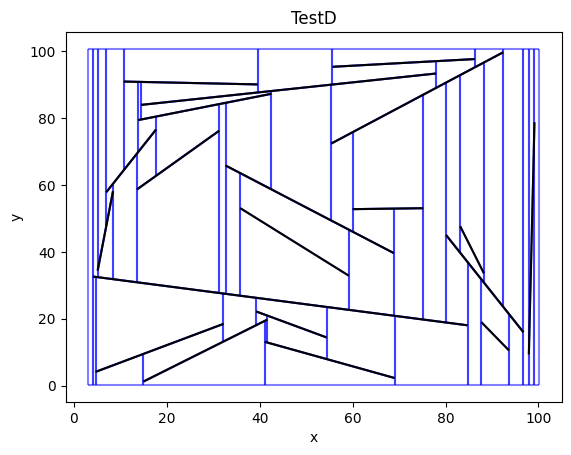

In [17]:
i=0
for i in range(len(tests_name)):
    formatted_segments=[]
    for (p1_coords, p2_coords) in tests_segments[i]:
        p1=Point(float(p1_coords[0]), float(p1_coords[1]))
        p2=Point(float(p2_coords[0]), float(p2_coords[1]))
        formatted_segments.append(Segment(p1, p2))
    min_x,min_y,max_x,max_y=get_bounding_box(formatted_segments)
    x=random.uniform(min_x,max_x)
    y=random.uniform(min_y,max_y)
    root=build_trapezoidal_map(formatted_segments,(x,y))
    vis=draw_actual(root)
    vis.add_line_segment(tests_segments[i],color='black')
    vis.add_title(tests_name[i])
    vis.save("Mapa_trapezowa_"+tests_name[i])
    vis.show()
    vis.clear()
    i+=1

<font size="4"><b>Funckja zwracajaca wynik graficznie</b></font>

In [18]:
def build_trapezoidal_map_visualization(data_from_generator):
    test_segments=[]
    for line in data_from_generator:
        if isinstance(line,Segment):
            test_segments.append(line)
        else:
            (x1,y1),(x2,y2)=line
            test_segments.append(Segment(Point(float(x1),float(y1)),Point(float(x2),float(y2))))
    
    segments_copy=test_segments.copy()
    random.shuffle(segments_copy)

    min_x,min_y,max_x,max_y=get_bounding_box(segments_copy)
    margin=0.5
    root=init_tree(min_x-margin,min_y-margin,max_x+margin,max_y+margin)
    
    vis=Visualizer()
    
    initial_box=[
        ((min_x-margin,min_y-margin),(max_x+margin,min_y-margin)),
        ((max_x+margin,min_y-margin),(max_x+margin,max_y+margin)),
        ((max_x+margin,max_y+margin),(min_x-margin,max_y+margin)),
        ((min_x-margin,max_y+margin),(min_x-margin,min_y-margin))
    ]
    vis.add_line_segment(initial_box,color="blue",linestyle="-")
    current_trapezoids_vis=None
    
    for seg in segments_copy:
        if current_trapezoids_vis:
            vis.remove_figure(current_trapezoids_vis)
        
        root=add_segment(root,seg)
        new_seg_coords =[((seg.p1.x,seg.p1.y),(seg.p2.x,seg.p2.y))]
        vis.add_line_segment(new_seg_coords,color="black",linewidth=2)
        current_traps=[]
        get_all_trapezoids(root,set(),current_traps)
        
        lines=set()
        for t in current_traps:
            y_tl=get_y_on_edge(t.top,t.left_p.x)
            y_bl=get_y_on_edge(t.bottom,t.left_p.x)
            y_tr=get_y_on_edge(t.top,t.right_p.x)
            y_br=get_y_on_edge(t.bottom,t.right_p.x)

            lines.add(((t.left_p.x,y_bl),(t.left_p.x,y_tl)))
            lines.add(((t.right_p.x,y_br),(t.right_p.x,y_tr)))
        
        current_trapezoids_vis=vis.add_line_segment(list(lines),color="blue",linestyle="-",alpha=0.5)
    
    if current_trapezoids_vis:
        vis.remove_figure(current_trapezoids_vis)
    
    current_traps=[]
    get_all_trapezoids(root,set(),current_traps)
    lines=set()
    for t in current_traps:
        y_tl=get_y_on_edge(t.top,t.left_p.x)
        y_bl=get_y_on_edge(t.bottom,t.left_p.x)
        y_tr=get_y_on_edge(t.top,t.right_p.x)
        y_br=get_y_on_edge(t.bottom,t.right_p.x)
        lines.add(((t.left_p.x,y_bl),(t.left_p.x,y_tl)))
        lines.add(((t.right_p.x,y_br),(t.right_p.x,y_tr)))
    
    vis.add_line_segment(list(lines),color="blue",linestyle="-",alpha=0.5)
    return root,vis

In [19]:
def graphical_result(data_from_generator,point):
    root,vis=build_trapezoidal_map_visualization(data_from_generator)
    x,y=point[0],point[1]
    
    found_trap=locate(root,Point(x,y))
    
    lines_trap=[]

    bottom,top=found_trap.bottom,found_trap.top
    left_p,right_p=found_trap.left_p,found_trap.right_p
    p1_b,p2_b=bottom.p1,bottom.p2
    p1_t,p2_t=top.p1,top.p2
    
  
    y_tl=get_y_on_edge(top,left_p.x)
    y_bl=get_y_on_edge(bottom,left_p.x)
    y_tr=get_y_on_edge(top,right_p.x)
    y_br=get_y_on_edge(bottom,right_p.x)

    line_bottom=((left_p.x,y_bl),(right_p.x,y_br))
    line_top=((left_p.x,y_tl),(right_p.x,y_tr))
    
    line_left=((left_p.x,y_bl),(left_p.x,y_tl))
    line_right=((right_p.x,y_br),(right_p.x,y_tr))

    lines_trap=[line_bottom,line_top,line_left,line_right]
    
    vis.add_line_segment(lines_trap, color="yellow", linestyle="-")
    vis.add_title("Punkt: "+ str((round(x,2),round(y,2))) +" znajduje się w trapezie o ID: "+ str(found_trap.id) )
    vis.add_point(point,color="red")
    vis.show()
    


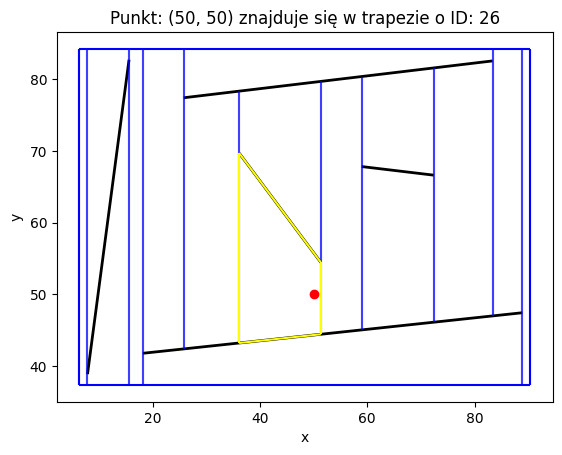

In [20]:
graphical_result(get_segments(),(50,50))

<font size="4"><b>Wyniki dla danych testowych </b></font>

In [21]:
i=0
for i in range(len(tests_name)):
    formatted_segments=[]
    for (p1_coords, p2_coords) in tests_segments[i]:
        p1=Point(float(p1_coords[0]), float(p1_coords[1]))
        p2=Point(float(p2_coords[0]), float(p2_coords[1]))
        formatted_segments.append(Segment(p1, p2))
    min_x,min_y,max_x,max_y=get_bounding_box(formatted_segments)
    x=random.uniform(min_x,max_x)
    y=random.uniform(min_y,max_y)
    _=run_test(tests_segments[i],(x,y))
    print("")
    print("--------------------------------------------------------------------")
    print("")
    
    i+=1
    

Punkt (53.95, 77.43) znajduje się w trapezie o ID: 7
Granice trapezu:
 Góra: (16.39, 82.53) -> (86.06, 77.74)
 Dół:  (38.32, 66.61) -> (59.87, 31.51)

--------------------------------------------------------------------

Punkt (16.93, 27.16) znajduje się w trapezie o ID: 37
Granice trapezu:
 Góra: (10.00, 80.00) -> (50.00, 75.00)
 Dół:  (9.00, 24.00) -> (91.00, 24.00)

--------------------------------------------------------------------

Punkt (87.51, 45.10) znajduje się w trapezie o ID: 18
Granice trapezu:
 Góra: (7.52, 87.64) -> (92.48, 87.64)
 Dół:  (8.52, 11.82) -> (91.48, 10.62)

--------------------------------------------------------------------

Punkt (94.45, 45.93) znajduje się w trapezie o ID: 28
Granice trapezu:
 Góra: (3.06, 100.77) -> (100.13, 100.77)
 Dół:  (80.10, 45.07) -> (96.76, 15.95)

--------------------------------------------------------------------



<font size="4"><b>Wyniki graficzne dla danych testowych </b></font>

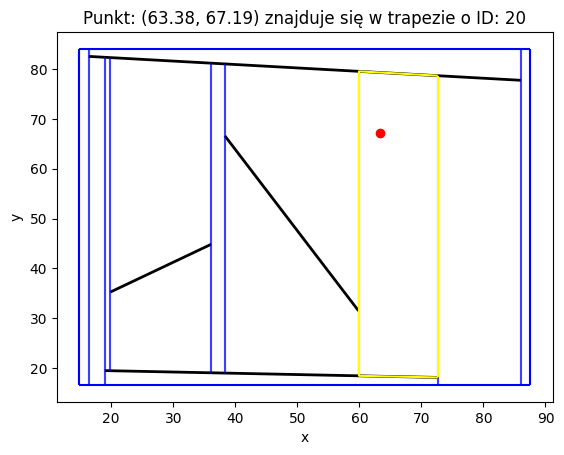

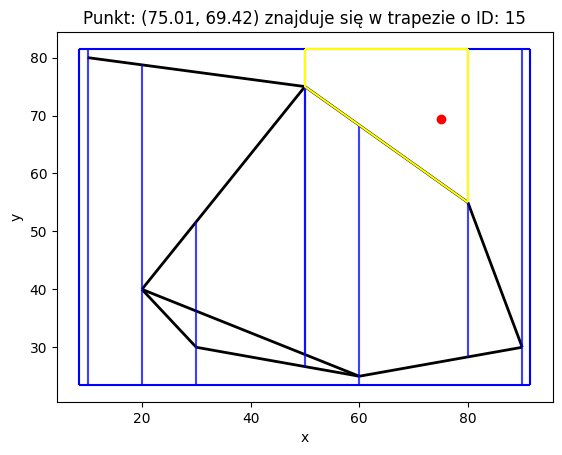

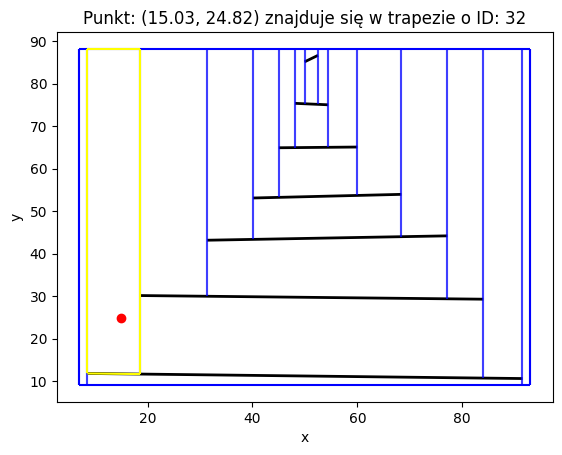

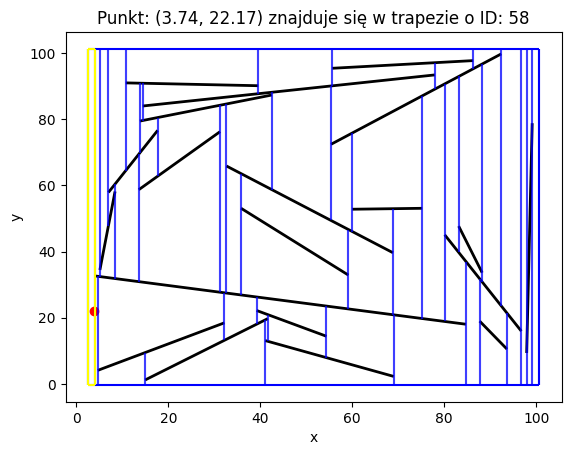

In [22]:
i=0
for i in range(len(tests_name)):
    formatted_segments=[]
    for (p1_coords, p2_coords) in tests_segments[i]:
        p1=Point(float(p1_coords[0]),float(p1_coords[1]))
        p2=Point(float(p2_coords[0]),float(p2_coords[1]))
        formatted_segments.append(Segment(p1, p2))
    min_x,min_y,max_x,max_y=get_bounding_box(formatted_segments)
    x=random.uniform(min_x,max_x)
    y=random.uniform(min_y,max_y)
    graphical_result(tests_segments[i],(x,y))
    i+=1

<font size="4"><b>Animacja powstawania mapy trapezowej dla danych testowych</b></font>

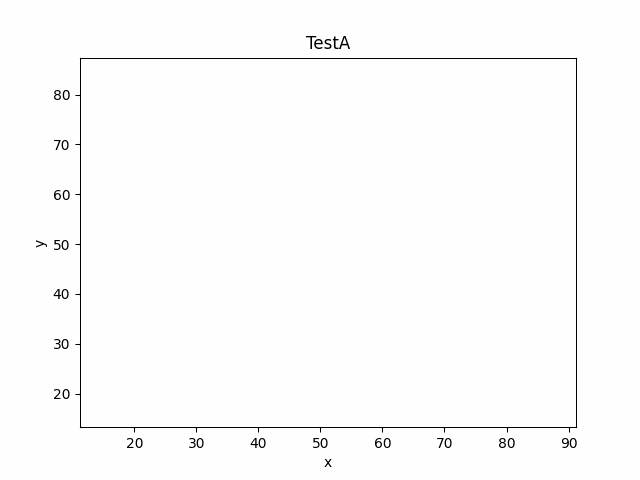

In [23]:
#Zbior A
root,vis=build_trapezoidal_map_visualization(tests_segments[0])
vis.add_title(tests_name[0])
vis.save_gif("Animacja mapy trapezowej"+ tests_name[0])
vis.show_gif(1500)   
    


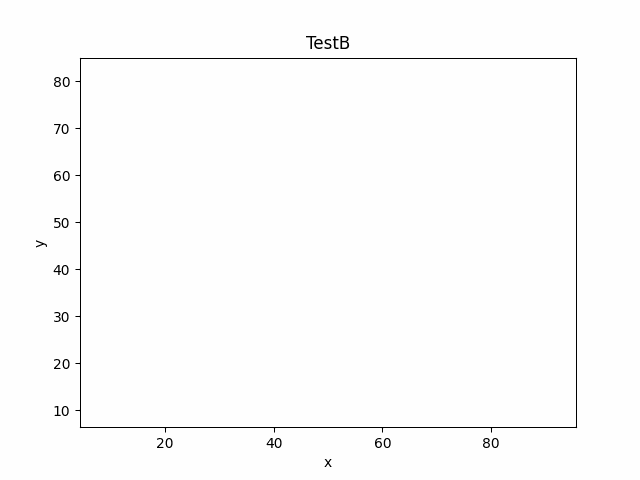

In [24]:
#Zbior B
root,vis=build_trapezoidal_map_visualization(tests_segments[1])
vis.add_title(tests_name[1])
vis.save_gif("Animacja mapy trapezowej"+ tests_name[1])
vis.show_gif(1500)   
    

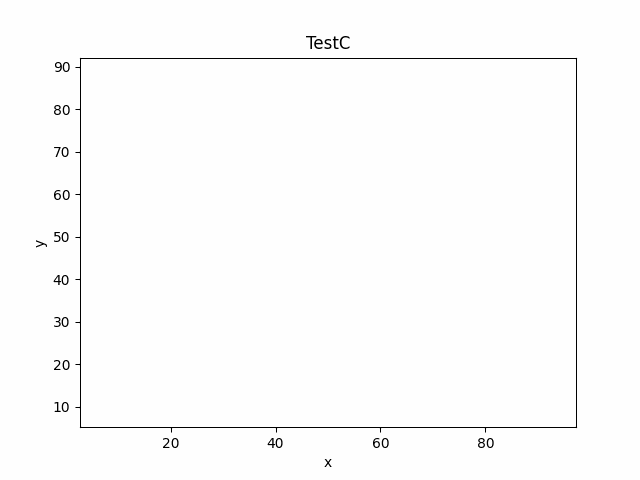

In [25]:
#Zbior C
root,vis=build_trapezoidal_map_visualization(tests_segments[2])
vis.add_title(tests_name[2])
vis.save_gif("Animacja mapy trapezowej"+ tests_name[2])
vis.show_gif(1500) 

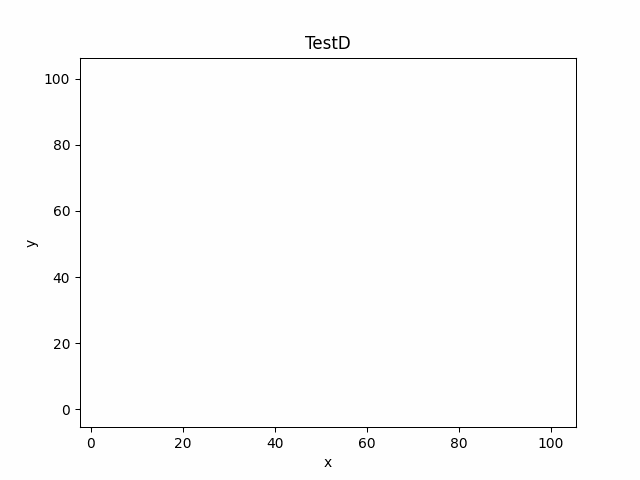

In [26]:
#Zbior D
root,vis=build_trapezoidal_map_visualization(tests_segments[3])
vis.add_title(tests_name[3])
vis.save_gif("Animacja mapy trapezowej"+ tests_name[3])
vis.show_gif(1500) 